<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab L: Nonlinearity

## Setup

In [29]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Your Own Jet Airplane

### Business Decision

Your company wants to buy a used Boeing 747.  This is the most popular airplane on the planet so many used 747s are available.

The data here describe 288 recent sales of Boeing 747s. For each sale, you have the transaction price (in millions $) and the total number of miles traveled at time of sale (in millions).

### Data

Retrieve data from file 'Airplane_Purchases.csv'.  Show the first few sales.

In [2]:
data = Table().read_table('Airplane_Purchases.csv')
data

mileage,price
65.3896,58.7512
28.5512,162.88
8.49768,309.676
66.8998,64.5737
45.697,84.7735
59.1262,71.2479
22.3089,151.944
61.093,84.5521
51.7692,86.7699
61.3561,94.4638


### Analysis: Linear Regression

Build a linear regression model to predict price based on mileage.  
Show the model goodness of fit (R^2).  
Show the model parameter values (intercept and coefficient).

In [3]:
model = ols('price ~ mileage', data).fit()
model.rsquared
model.params

0.85934511428814475

Intercept    315.161411
mileage       -3.922520
dtype: float64

Use the model to predict the sale prices.  
Show the first few predictions.

In [4]:
data = data.with_column('price_predicted', model.predict(data))
data

mileage,price,price_predicted
65.3896,58.7512,58.6693
28.5512,162.88,203.169
8.49768,309.676,281.829
66.8998,64.5737,52.7458
45.697,84.7735,135.914
59.1262,71.2479,83.2378
22.3089,151.944,227.654
61.093,84.5521,75.5228
51.7692,86.7699,112.096
61.3561,94.4638,74.4911


Visualize the model performance as a scatterplot of actual price and predicted price vs. mileage.

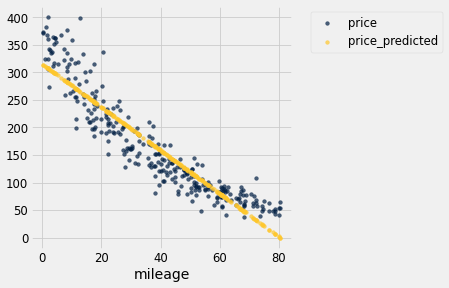

In [5]:
data.scatter('mileage')

Show the errors between the sale actual prices and predicted prices.

In [6]:
data = data.with_column('error', data.column('price')-data.column('price_predicted'))
data

mileage,price,price_predicted,error
65.3896,58.7512,58.6693,0.0819827
28.5512,162.88,203.169,-40.289
8.49768,309.676,281.829,27.8467
66.8998,64.5737,52.7458,11.8279
45.697,84.7735,135.914,-51.1406
59.1262,71.2479,83.2378,-11.9899
22.3089,151.944,227.654,-75.71
61.093,84.5521,75.5228,9.02928
51.7692,86.7699,112.096,-25.3257
61.3561,94.4638,74.4911,19.9727


Visualize the errors as a scatterplot.

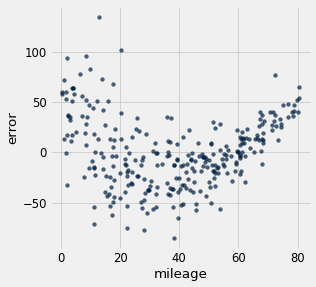

In [7]:
data.select('mileage', 'error').scatter('mileage')

Use the model to predict the price of a Boeing 747 that has traveled 50 million miles.

In [8]:
my_mileage = 50
my_price_predicted = model.predict(Table().with_column('mileage', my_mileage))
my_price_predicted

0    119.035426
dtype: float64

### Analysis: Linear-Log Regression

Reset dataset to include mileage and price variables only.

In [9]:
data = data.select('mileage','price')

Add a variable for log mileage.  You can use the `log()` function.  
Show the first few observations of the resulting dataset. 

In [10]:
data = data.with_column('log_mileage', log(data.column('mileage')))
data

mileage,price,log_mileage
65.3896,58.7512,4.18036
28.5512,162.88,3.3517
8.49768,309.676,2.13979
66.8998,64.5737,4.2032
45.697,84.7735,3.82203
59.1262,71.2479,4.07967
22.3089,151.944,3.10499
61.093,84.5521,4.1124
51.7692,86.7699,3.9468
61.3561,94.4638,4.11669


Build a linear regression model to predict price based on log mileage.  
Show the model goodness of fit (R^2).  
Show the model parameter values (intercept and coefficient).

In [12]:
model = ols('price ~ log_mileage', data).fit()
model.rsquared
model.params

0.81525737933190223

Intercept      453.880889
log_mileage    -86.289307
dtype: float64

Use the model to predict the sale prices.  
Show the first few predictions.

In [13]:
data = data.with_column('price_predicted', model.predict(data))
data

mileage,price,log_mileage,price_predicted
65.3896,58.7512,4.18036,93.1602
28.5512,162.88,3.3517,164.665
8.49768,309.676,2.13979,269.24
66.8998,64.5737,4.2032,91.1901
45.697,84.7735,3.82203,124.08
59.1262,71.2479,4.07967,101.849
22.3089,151.944,3.10499,185.954
61.093,84.5521,4.1124,99.0249
51.7692,86.7699,3.9468,113.315
61.3561,94.4638,4.11669,98.6542


Visualize the model performance as a scatterplot of actual price and predicted price vs. log mileage.

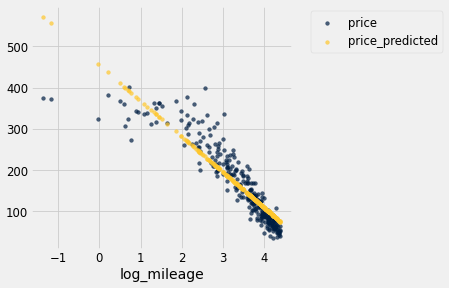

In [14]:
data.select('log_mileage','price','price_predicted').scatter('log_mileage')

Visualize the model performance as a scatterplot of actual price and predicted price vs. mileage.

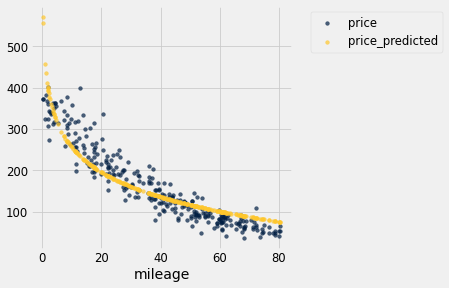

In [15]:
data.select('mileage', 'price', 'price_predicted').scatter('mileage')

Show the errors between the sale actual prices and predicted prices.

In [16]:
data = data.with_column('error', data.column('price')-data.column('price_predicted'))
data

mileage,price,log_mileage,price_predicted,error
65.3896,58.7512,4.18036,93.1602,-34.409
28.5512,162.88,3.3517,164.665,-1.78536
8.49768,309.676,2.13979,269.24,40.4362
66.8998,64.5737,4.2032,91.1901,-26.6164
45.697,84.7735,3.82203,124.08,-39.3069
59.1262,71.2479,4.07967,101.849,-30.6008
22.3089,151.944,3.10499,185.954,-34.0095
61.093,84.5521,4.1124,99.0249,-14.4729
51.7692,86.7699,3.9468,113.315,-26.5447
61.3561,94.4638,4.11669,98.6542,-4.19046


Visualize the errors as a scatterplot.

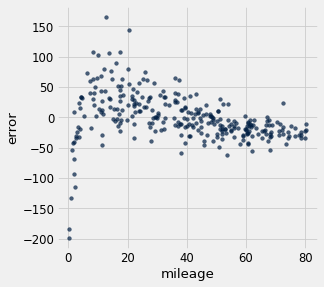

In [17]:
data.select('mileage', 'error').scatter('mileage')

Use the model to predict the price of a Boeing 747 that has traveled 50 million miles.

In [18]:
my_mileage = 50
my_log_mileage = log(my_mileage)
my_price_predicted = model.predict(Table().with_column('log_mileage', my_log_mileage))
my_price_predicted

0    116.315137
dtype: float64

### Analysis: Log-Linear Regression

Reset dataset to include mileage and price variables only.

In [19]:
data = data.select('mileage','price')

Add a variable for log price.  You can use the `log()` function.  
Show the first few observations of the resulting dataset. 

In [20]:
data = data.with_column('log_price', log(data.column('price')))
data

mileage,price,log_price
65.3896,58.7512,4.07331
28.5512,162.88,5.09301
8.49768,309.676,5.73553
66.8998,64.5737,4.16781
45.697,84.7735,4.43998
59.1262,71.2479,4.26617
22.3089,151.944,5.02351
61.093,84.5521,4.43737
51.7692,86.7699,4.46326
61.3561,94.4638,4.54822


Build a linear regression model to predict log price based on mileage.  
Show the model goodness of fit (R^2).  
Show the model parameter values (intercept and coefficient).

In [21]:
model = ols('log_price ~ mileage', data).fit()
model.rsquared
model.params

0.91236085612365947

Intercept    5.915149
mileage     -0.025407
dtype: float64

Use the model to predict the sale log prices.
Show the first few predictions.

In [22]:
data = data.with_column('log_price_predicted', model.predict(data))
data

mileage,price,log_price,log_price_predicted
65.3896,58.7512,4.07331,4.25377
28.5512,162.88,5.09301,5.18973
8.49768,309.676,5.73553,5.69924
66.8998,64.5737,4.16781,4.2154
45.697,84.7735,4.43998,4.75411
59.1262,71.2479,4.26617,4.4129
22.3089,151.944,5.02351,5.34834
61.093,84.5521,4.43737,4.36293
51.7692,86.7699,4.46326,4.59982
61.3561,94.4638,4.54822,4.35625


Visualize the model performance as a scatterplot of actual log price and predicted log price vs. mileage.

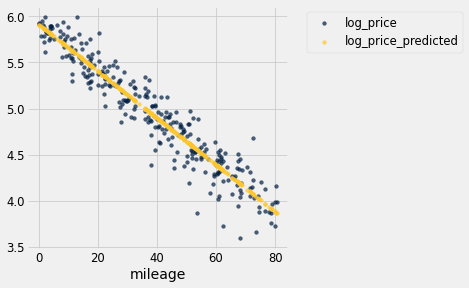

In [23]:
data.select('mileage','log_price','log_price_predicted').scatter('mileage')

Predict the sale prices.  Show the first few predictions. You can use the `exp()` function.

In [24]:
data = data.with_column('price_predicted', exp(data.column('log_price_predicted')))
data

mileage,price,log_price,log_price_predicted,price_predicted
65.3896,58.7512,4.07331,4.25377,70.3699
28.5512,162.88,5.09301,5.18973,179.421
8.49768,309.676,5.73553,5.69924,298.642
66.8998,64.5737,4.16781,4.2154,67.721
45.697,84.7735,4.43998,4.75411,116.06
59.1262,71.2479,4.26617,4.4129,82.5087
22.3089,151.944,5.02351,5.34834,210.258
61.093,84.5521,4.43737,4.36293,78.4868
51.7692,86.7699,4.46326,4.59982,99.4669
61.3561,94.4638,4.54822,4.35625,77.9641


Visualize the model performance as a scatterplot of actual price and predicted price vs. mileage.

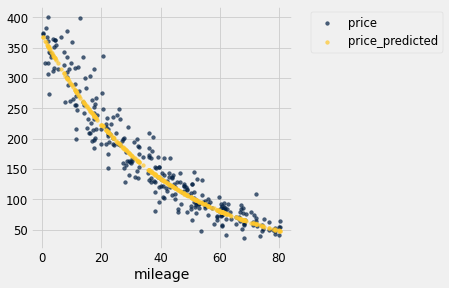

In [25]:
data.select('mileage', 'price', 'price_predicted').scatter('mileage')

Show the errors between the sale actual prices and predicted prices.

In [26]:
data = data.with_column('error', data.column('price')-data.column('price_predicted'))
data

mileage,price,log_price,log_price_predicted,price_predicted,error
65.3896,58.7512,4.07331,4.25377,70.3699,-11.6186
28.5512,162.88,5.09301,5.18973,179.421,-16.5413
8.49768,309.676,5.73553,5.69924,298.642,11.0341
66.8998,64.5737,4.16781,4.2154,67.721,-3.14737
45.697,84.7735,4.43998,4.75411,116.06,-31.2863
59.1262,71.2479,4.26617,4.4129,82.5087,-11.2608
22.3089,151.944,5.02351,5.34834,210.258,-58.3139
61.093,84.5521,4.43737,4.36293,78.4868,6.06522
51.7692,86.7699,4.46326,4.59982,99.4669,-12.697
61.3561,94.4638,4.54822,4.35625,77.9641,16.4997


Visualize the errors as a scatterplot.

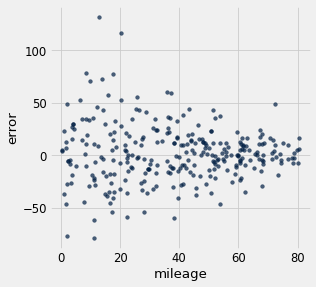

In [27]:
data.select('mileage', 'error').scatter('mileage')

Use the model to predict the price of a Boeing 747 that has traveled 50 million miles.

In [28]:
my_mileage = 50
my_log_price_predicted = model.predict(Table().with_column('mileage', my_mileage))
my_price_predicted = exp(my_log_price_predicted)
my_price_predicted

0    104.040122
dtype: float64

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised November 10, 2023
</span>
</p>